# RQ1 Statistics — JavaScript replication

Reproduces, for **JavaScript**, the numbers reported in the Java RQ1 paragraph of the Stack Overflow answer-edit study:

- number of accepted answers (baseline denominator)
- number of code snippets + avg/std per answer (latest version)
- number of answers with ≥ 1 revision + percentage (the filtered set)
- average / median / max revisions per answer
- total code snippets across all revisions
- the answer with the most revisions (+ its date span)
- a revisions-distribution histogram (`javascript_post_revisions_histogram.pdf`)

The filtered set is read from the answer-id file produced by `extract_answer_list.py`.
Baseline figures are computed over *all* accepted answers for the tag.

Run the cells in order. Configure the connection and paths in the **Configuration** cell.

In [1]:
!pip install mysql-connector-python matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Configuration

In [2]:
import statistics
import time
from pathlib import Path

import mysql.connector
import matplotlib.pyplot as plt

# --- connection ---
HOST = "127.0.0.1"
USER = "root"
PASSWORD = ""
DATABASE = "sotorrent"

# --- study parameters (assumes the notebook runs from the analysis/ directory) ---
TAG = "javascript"
ANSWER_LIST = Path("../files/acceptedWithVersionAnswer_javascript.txt")  # output of extract_answer_list.py
HIST_OUTPUT = Path("javascript_post_revisions_histogram.pdf")
SKIP_BASELINE = False  # set True to skip the slow all-accepted-answers baseline queries

INSERT_BATCH = 20_000

## Connect and resolve the tag id

In [3]:
db = mysql.connector.connect(host=HOST, user=USER, password=PASSWORD, database=DATABASE)
cursor = db.cursor()

cursor.execute("SELECT Id, Count FROM Tags WHERE TagName = %s", (TAG,))
row = cursor.fetchone()
if row is None:
    raise ValueError(f"Tag '{TAG}' not found in the Tags table.")
tag_id, tag_count = row
print(f"Tag '{TAG}' -> TagId {tag_id} ({tag_count:,} questions)")

Tag 'javascript' -> TagId 3 (2,130,783 questions)


## Baseline: all accepted answers for the tag

Builds a temporary table of every accepted answer for the tag, then counts latest-version code snippets per answer (including answers with zero code blocks). Skipped if `SKIP_BASELINE = True`. These queries touch the full accepted set, so they can take a few minutes.

In [4]:
baseline = None
if not SKIP_BASELINE:
    t0 = time.perf_counter()
    cursor.execute("DROP TEMPORARY TABLE IF EXISTS _rq1_all_accepted")
    cursor.execute("CREATE TEMPORARY TABLE _rq1_all_accepted (Id INT PRIMARY KEY)")

    # Fetch the accepted-answer ids with a plain (non-locking) read, then load them
    # in committed batches. Doing this as a single INSERT ... SELECT holds InnoDB
    # locks on every scanned row for the whole statement and trips error 1206
    # ("total number of locks exceeds the lock table size") on large tags.
    cursor.execute(
        """
        SELECT q.AcceptedAnswerId
        FROM Posts q
        JOIN PostTags pt ON pt.PostId = q.Id AND pt.TagId = %s
        WHERE q.PostTypeId = 1 AND q.AcceptedAnswerId IS NOT NULL
        """,
        (tag_id,),
    )
    accepted_ids = [r[0] for r in cursor.fetchall()]
    for i in range(0, len(accepted_ids), INSERT_BATCH):
        batch = accepted_ids[i:i + INSERT_BATCH]
        cursor.executemany("INSERT IGNORE INTO _rq1_all_accepted (Id) VALUES (%s)", [(x,) for x in batch])
        db.commit()

    cursor.execute("SELECT COUNT(*) FROM _rq1_all_accepted")
    total_accepted = cursor.fetchone()[0]
    print(f"accepted answers: {total_accepted:,}  ({time.perf_counter() - t0:.0f}s)")

    print("counting latest-version code snippets per answer (may take minutes)...")
    t0 = time.perf_counter()
    cursor.execute(
        """
        SELECT COUNT(*)              AS answers,
               COALESCE(SUM(cnt), 0) AS snippets,
               AVG(cnt)              AS avg_snippets,
               STDDEV_SAMP(cnt)      AS std_snippets
        FROM (
            SELECT aa.Id, COUNT(pbv.Id) AS cnt
            FROM _rq1_all_accepted aa
            LEFT JOIN PostBlockVersion pbv
                   ON pbv.PostId = aa.Id
                  AND pbv.PostBlockTypeId = 2
                  AND pbv.MostRecentVersion = 1
            GROUP BY aa.Id
        ) x
        """
    )
    _, snippets, avg_snip, std_snip = cursor.fetchone()
    baseline = {
        "total_accepted": total_accepted,
        "total_snippets": int(snippets),
        "avg_snippets": float(avg_snip),
        "std_snippets": float(std_snip),
    }
    print(f"code snippets: {baseline['total_snippets']:,}  "
          f"avg {baseline['avg_snippets']:.2f}/answer, std {baseline['std_snippets']:.2f}  "
          f"({time.perf_counter() - t0:.0f}s)")
else:
    print("baseline skipped")

accepted answers: 1,144,185  (603s)
counting latest-version code snippets per answer (may take minutes)...


code snippets: 1,591,776  avg 1.39/answer, std 1.24  (322s)


## Filtered set: select the revised accepted answers

Selects the filtered set straight from SOTorrent with the same predicate as
`extract_answer_list.py` — accepted, parent question carries the tag, and edited at least
once (`PredPostHistoryId IS NOT NULL`) — and loads it into a temporary table.

Deriving the set here rather than reading a previously written id file guarantees that the
numerator of the percentage below and the baseline denominator are computed in the same
session under the same definition, and that every language uses a provably identical
predicate. The answer-id file is still cross-checked against the query result, so a stale
file, or one built with `--require-code-block`, is reported rather than silently used.

In [ ]:
# Same predicate as extract_answer_list.py and as the Java study: accepted answer of a
# question carrying the tag, edited at least once.
FILTERED_SET_SQL = """
    SELECT a.Id
    FROM Posts q
    JOIN PostTags pt ON pt.PostId = q.Id AND pt.TagId = %s
    JOIN Posts    a  ON a.Id = q.AcceptedAnswerId
    WHERE q.PostTypeId = 1
      AND EXISTS (SELECT 1 FROM PostVersion pv
                  WHERE pv.PostId = a.Id AND pv.PredPostHistoryId IS NOT NULL)
"""

print("selecting revised accepted answers...")
cursor.execute(FILTERED_SET_SQL, (tag_id,))
ids = [row[0] for row in cursor.fetchall()]
filtered_total = len(ids)
print(f"{filtered_total:,} answers")

cursor.execute("DROP TEMPORARY TABLE IF EXISTS _rq1_filtered")
cursor.execute("CREATE TEMPORARY TABLE _rq1_filtered (Id INT PRIMARY KEY)")
for i in range(0, len(ids), INSERT_BATCH):
    batch = ids[i:i + INSERT_BATCH]
    cursor.executemany("INSERT IGNORE INTO _rq1_filtered (Id) VALUES (%s)", [(x,) for x in batch])
db.commit()

# Cross-check against the id file the extraction stage consumed, if it is present.
if ANSWER_LIST.exists():
    file_ids = {int(line) for line in ANSWER_LIST.read_text().split() if line.strip()}
    query_ids = set(ids)
    if file_ids == query_ids:
        print(f"cross-check: matches {ANSWER_LIST.name} exactly")
    else:
        print(f"WARNING: {ANSWER_LIST.name} disagrees with the query")
        print(f"  in file only:  {len(file_ids - query_ids):,}")
        print(f"  in query only: {len(query_ids - file_ids):,}")
        print("  the query result is used; rerun extract_answer_list.py to refresh the file.")
else:
    print(f"cross-check skipped, {ANSWER_LIST} not found")

## Filtered set: revision counts, snippets, and the most-revised answer

In [6]:
print("counting versions per answer...")
cursor.execute(
    """
    SELECT pv.PostId, COUNT(*) AS versions
    FROM PostVersion pv
    JOIN _rq1_filtered t ON t.Id = pv.PostId
    GROUP BY pv.PostId
    """
)
counts = {post_id: versions for post_id, versions in cursor.fetchall()}
revisions = list(counts.values())

print("counting code snippets across all revisions...")
cursor.execute(
    """
    SELECT COUNT(*)
    FROM PostBlockVersion pbv
    JOIN _rq1_filtered t ON t.Id = pbv.PostId
    WHERE pbv.PostBlockTypeId = 2
    """
)
snippets_all_revisions = cursor.fetchone()[0]

most_revised_id = max(counts, key=counts.get)
cursor.execute(
    "SELECT MIN(CreationDate), MAX(CreationDate) FROM PostVersion WHERE PostId = %s",
    (most_revised_id,),
)
most_revised_first, most_revised_last = cursor.fetchone()
print("done")

counting versions per answer...


counting code snippets across all revisions...


done


## Revisions-distribution histogram

Histogram saved to: javascript_post_revisions_histogram.pdf


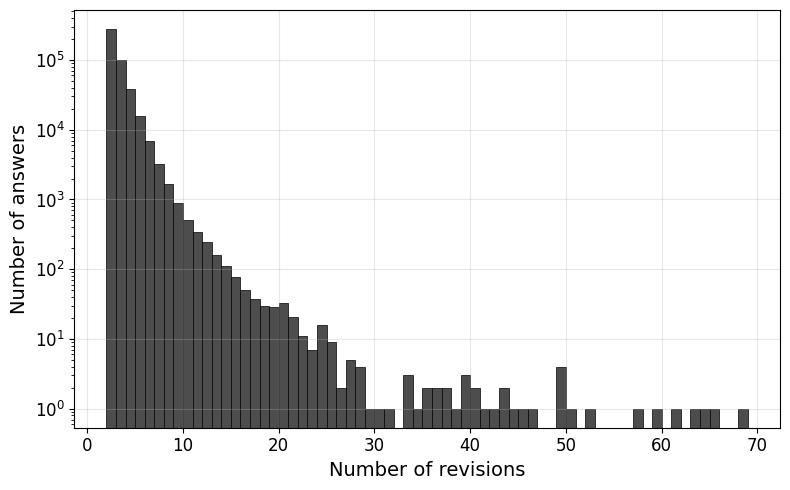

In [7]:
max_rev = max(revisions)
bins = range(min(revisions), max_rev + 2)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(revisions, bins=bins, color="#4d4d4d", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of revisions", fontsize=14)
ax.set_ylabel("Number of answers", fontsize=14)
ax.set_yscale("log")
ax.tick_params(axis="both", which="major", labelsize=12)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(HIST_OUTPUT, dpi=300, bbox_inches="tight", format="pdf")
print(f"Histogram saved to: {HIST_OUTPUT}")
plt.show()

## Levenshtein distances

Edit distance between each answer's original and most recent code snippet, computed by
`code_diff.py` over the `javascript_files/` tree written by the revision-extraction stage.

The full scan is slow and rewrites a large CSV, so it is opt-in: flip
`RUN_DISTANCE_COMPUTATION` to `True` to (re)build the CSV. Otherwise the existing CSV is
reused, exactly like `RUN_FULL_EXTRACTION` in the extraction notebooks.

In [3]:
import sys

# code_diff.py sits next to this notebook in analysis/
sys.path.insert(0, str(Path.cwd()))
from code_diff import (
    find_and_compute_distances,
    save_distances_to_csv,
    read_distances_from_csv,
    analyze_levenshtein_distances,
    print_statistics,
    generate_boxplot,
    add_filename_suffix,
)

# Snippet tree produced by the revision-extraction stage, one level above the repo root
CODE_DIR = Path("../..") / "javascript_files"
EXTENSION = "js"
DISTANCE_CSV = Path("levenshtein_distances_javascript.csv")
BOXPLOT_OUTPUT = Path("../javascript_levenshtein_boxplot.png")

RUN_DISTANCE_COMPUTATION = False  # flip to True to actually (re)compute the distances

if RUN_DISTANCE_COMPUTATION:
    if not CODE_DIR.is_dir():
        raise FileNotFoundError(
            f"{CODE_DIR} does not exist - run the JavaScript revision extraction first"
        )
    pairs = find_and_compute_distances(str(CODE_DIR), EXTENSION)
    if pairs:
        save_distances_to_csv(pairs, str(DISTANCE_CSV))
        print(f"\nSaved {len(pairs):,} distances to {DISTANCE_CSV}")
    else:
        print(f"\nNo *_original.js / *_recent.js pairs found under {CODE_DIR}")
elif DISTANCE_CSV.exists():
    size_mb = DISTANCE_CSV.stat().st_size / 1024**2
    print(f"Reusing existing {DISTANCE_CSV} ({size_mb:,.1f} MB)")
    print("Set RUN_DISTANCE_COMPUTATION = True to rebuild it.")
else:
    print(f"{DISTANCE_CSV} not found.")
    print("Set RUN_DISTANCE_COMPUTATION = True to build it.")

Reusing existing levenshtein_distances_javascript.csv (155.2 MB)
Set RUN_DISTANCE_COMPUTATION = True to rebuild it.


## Levenshtein-distance boxplots

Two versions are written: the full distribution, and a second `_no_outliers` pair with the
fliers hidden. A handful of very large edits otherwise stretch the axis so far that the box
and whiskers collapse into an unreadable sliver at zero.


Statistical Analysis Results:
  Number of pairs analyzed: 793362
  Minimum distance: 0
  Maximum distance: 20690
  Mean distance: 48.66
  Median distance: 0.0
  Standard deviation: 228.44

Horizontal boxplot saved to: ../javascript_levenshtein_boxplot.png
Horizontal boxplot saved as PDF: ../javascript_levenshtein_boxplot.pdf


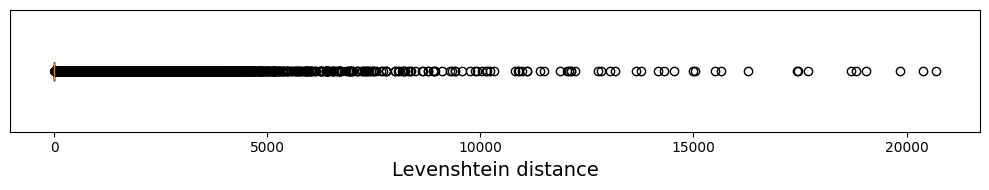

Horizontal boxplot saved to: ../javascript_levenshtein_boxplot_no_outliers.png
Horizontal boxplot saved as PDF: ../javascript_levenshtein_boxplot_no_outliers.pdf


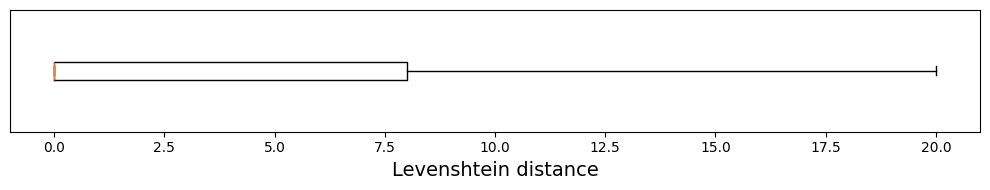

In [4]:
distances = read_distances_from_csv(str(DISTANCE_CSV))

if distances:
    stats = analyze_levenshtein_distances(distances=distances)
    print_statistics(stats)

    print()
    generate_boxplot(distances, str(BOXPLOT_OUTPUT), show_outliers=True)
    generate_boxplot(
        distances,
        add_filename_suffix(str(BOXPLOT_OUTPUT), "_no_outliers"),
        show_outliers=False,
    )
else:
    print("No distances available - run the cell above with RUN_DISTANCE_COMPUTATION = True")

## RQ1 summary

In [8]:
print("=" * 70)
print(f"RQ1 STATISTICS - tag '{TAG}'")
print("=" * 70)
if baseline:
    pct = 100.0 * filtered_total / baseline["total_accepted"]
    print(f"Accepted answers:                 {baseline['total_accepted']:,}")
    print(f"Code snippets (latest version):   {baseline['total_snippets']:,}")
    print(f"  avg per answer:                 {baseline['avg_snippets']:.2f}")
    print(f"  std:                            {baseline['std_snippets']:.2f}")
    print(f"Answers with >= 1 revision:       {filtered_total:,} ({pct:.2f}%)")
else:
    print(f"Answers with >= 1 revision:       {filtered_total:,} (baseline skipped -> no percentage)")
print(f"Avg revisions per answer:         {statistics.mean(revisions):.2f}")
print(f"Median revisions per answer:      {statistics.median(revisions):.1f}")
print(f"Std revisions per answer:         {statistics.pstdev(revisions):.2f}")
print(f"Max revisions:                    {counts[most_revised_id]} (post ID {most_revised_id})")
print(f"  first revision:                 {most_revised_first}")
print(f"  last revision:                  {most_revised_last}")
print(f"Code snippets across all revs:    {snippets_all_revisions:,}")
print("=" * 70)

RQ1 STATISTICS - tag 'javascript'
Accepted answers:                 1,144,185
Code snippets (latest version):   1,591,776
  avg per answer:                 1.39
  std:                            1.24
Answers with >= 1 revision:       447,379 (39.10%)
Avg revisions per answer:         2.68
Median revisions per answer:      2.0


Std revisions per answer:         1.31
Max revisions:                    68 (post ID 9550412)
  first revision:                 2012-03-03 22:24:30
  last revision:                  2020-11-26 21:47:46
Code snippets across all revs:    1,998,016


## Close the connection

In [9]:
cursor.close()
db.close()
print("connection closed")

connection closed
